# BH vs HMNS engines for kilonova-bearing GRBs

## Methods

Eight kilonova-bearing GRBs from Rastinejad et al. (2024, ApJ 979, 190; Tables 1, 3) are tested against two engines.

**(i) BH engine.** Gottlieb et al. (2025, arXiv:2411.13657) Eq. (11):
$M_{\rm ej} = 10^{-3}\,f_{-1}^{-1}\,(E_{\gamma,\rm iso}/2{\times}10^{51}\,{\rm erg})\,(T_{50}/{\rm s})^{\alpha-1}\,M_\odot$.
The band marginalises $\alpha \in [1.5, 2]$ and $f^{-1} \in [0.14, 5]$ (Gottlieb+25 Eq. 10 with $\epsilon_\gamma \in [0.15, 0.5]$, $f_b \in [0.01, 0.11]$).

**(ii) HMNS / magnetar disk-wind.** $M_{\rm ej} = 0.3\,M_d$ (Gottlieb+25 §3.1; Radice et al. 2018, arXiv:1809.11163), with $M_d \in [0.01, 0.10]\,M_\odot$ from Krüger & Foucart (2020, arXiv:2002.07728, Eq. 4).

Per-event $T_{50}$ overrides for 050709 (Villasenor+05), 170817A (Goldstein+17), and 230307A ($T_{90}/2$, Levan+24) are documented in [`Data/rastinejad_2024.csv`](Data/rastinejad_2024.csv). Posteriors use $10^4$ MC draws over the Rastinejad split-normal $M_{\rm ej}$ and the $E_{\gamma,\rm iso}$, $\alpha$, $f$ priors. Per-subclass mean log-ratios and Gaussian-in-log Bayes factors $B_{10} = P({\rm data}\mid{\rm HMNS}) / P({\rm data}\mid{\rm BH})$ are printed below Fig. 2.

## Figures

**Figure 1.** $M_{\rm ej}$ vs $T_{50}$. Grey BH band centred on the in-sample lbGRB geomean of $E_{\gamma,\rm iso}$ (the anchor value is printed in the legend). Inner shading: $\alpha \in [1.5, 2]$. Outer dashed envelope: adds $f^{-1} \in [0.14, 5]$. Green HMNS strip: $M_{\rm ej} = 0.3\,M_d$ for $M_d \in [0.01, 0.10]\,M_\odot$ (Gottlieb+25 §3.1); the short green $t_{\rm HMNS} \in [0.1, 10]\,{\rm s}$ bracket at the left edge is a timescale guide only (Lippuner+17, Fujibayashi+18, Metzger 2019), not a prediction along the $y$ axis. Bars are 68% on $M_{\rm tot}$ and $T_{50}$. The upper-left footnote flags the $T_{50} = T_{90}/2$ convention for 230307A. The companion panel (`plot_fig1_composition`) shows the per-event lanthanide-rich / intermediate / lanthanide-poor mass fractions ($M_R$, $M_P$, $M_B$) from Rastinejad+24 Table 3.

**Figure 2.** $\log_{10}(M_{\rm obs}/M_{\rm pred,BH})$ per event, 68% MC bars on the joint $(M_{\rm obs}, E_{\gamma,\rm iso}, \alpha, f, T_{50})$ posterior. Teal `+` is the HMNS prediction over log-uniform $M_d$. Grey band: Gottlieb+25 factor-of-3 agreement criterion. GW170817 has no $y$-bar; its prompt $E_{\gamma,\rm iso}$ is off-axis cocoon emission (Goldstein+17, Mooley+18), so Eq. 11 is misapplied.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from grb_physics import (
    GOTTLIEB25_F_RANGE,
    GOTTLIEB25_DISK_RANGE,
    GOTTLIEB25_WIND_FRAC,
    GOTTLIEB25_WIND_FRAC_RANGE,
    GOTTLIEB25_T_HMNS_RANGE,
    gottlieb25_eq11,
    hmns_wind_ejecta,
)

PLOTS_DIR = "Plots"
DATA_DIR  = "Data"
CSV_PATH  = os.path.join(DATA_DIR, "rastinejad_2024.csv")
os.makedirs(PLOTS_DIR, exist_ok=True)

# ApJ single-column rcParams. Caller scripts can override.
mpl.rcParams.update({
    "figure.figsize":     (3.5, 3.0),
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",
    "font.size":          8,
    "font.family":        "serif",
    "mathtext.fontset":   "cm",
    "axes.linewidth":     0.7,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.top":          True,
    "ytick.right":        True,
    "legend.fontsize":    7,
    "legend.frameon":     True,
    "legend.framealpha":  0.92,
    "lines.linewidth":    1.0,
})

# Read the canonical Rastinejad+24 table.  See CSV header for column
# definitions, the component-to-origin mapping (M_B dynamical vs
# M_P + M_R disk wind), and T_50 source notes.
df = pd.read_csv(CSV_PATH, comment="#", skipinitialspace=True)
df["E_iso_erg"]     = df["E_iso_52"]     * 1e52
df["E_iso_err_erg"] = df["E_iso_err52"]  * 1e52

# Per-event T_50 prior overrides.  Default is a clipped Gaussian with
# (T50_s, T50_err_s) from the CSV; events listed here use a log-space
# prior that honours the "upper bound only" (050709) and
# "T_90/2 with factor-2 width" (230307A) caveats documented in the CSV
# header.
#
#   ("logunif", lo, hi)   -- log-uniform on [lo, hi] (Jeffreys-type prior)
#   ("lognormal", mu, s)  -- ln T_50 ~ N(ln(mu), s)
T50_PRIOR_OVERRIDES = {
    "050709":  ("logunif",   0.02, 0.07),
    "230307A": ("lognormal", 17.5, np.log(2.0)),
}


def sample_T50(row, n, rng):
    """Draw ``n`` T_50 samples for one event honouring any prior override."""
    prior = T50_PRIOR_OVERRIDES.get(row["name"])
    if prior is None:
        return np.clip(
            rng.normal(row.T50_s, max(row.T50_err_s, 1e-3 * row.T50_s), n),
            1e-6 * row.T50_s, None,
        )
    kind = prior[0]
    if kind == "logunif":
        return 10.0 ** rng.uniform(np.log10(prior[1]), np.log10(prior[2]), n)
    if kind == "lognormal":
        return rng.lognormal(mean=np.log(prior[1]), sigma=prior[2], size=n)
    raise ValueError(f"Unknown T_50 prior kind: {kind!r}")


# ---------------------------------------------------------------------------
# Posterior sampling: split-normal sampler -> 1e4 draws of M_B, M_P, M_R,
# M_tot, and M_wind per event.  M_wind = M_P + M_R is the disk-wind mass
# used by the Fig. 2 residual (Metzger 2019 mapping; see CSV header).
# ---------------------------------------------------------------------------
def sample_split_normal(med, lo, hi, n, rng, clip_zero=True):
    """Draw n samples from a split-normal centered at `med` with half-widths
    `lo` (below) and `hi` (above), interpreted as 1-sigma.  Tiny widths
    fall back to a 5%-of-median floor so that posteriors with reported
    +/-0 stay finite.
    """
    floor = max(1e-6, 0.05 * abs(med))
    sigma_lo = max(abs(lo), floor)
    sigma_hi = max(abs(hi), floor)
    u = rng.uniform(size=n)
    above = u < sigma_hi / (sigma_lo + sigma_hi)
    z = np.abs(rng.standard_normal(n))
    out = np.where(above, med + sigma_hi * z, med - sigma_lo * z)
    if clip_zero:
        out = np.clip(out, 0.0, None)
    return out


def build_posteriors(df, n=10_000, seed=0):
    """For every GRB return n samples of M_B, M_P, M_R, M_tot, M_wind."""
    rng = np.random.default_rng(seed)
    out = {}
    for _, row in df.iterrows():
        m_b = sample_split_normal(row.M_B_med, row.M_B_lo, row.M_B_hi, n, rng)
        m_p = sample_split_normal(row.M_P_med, row.M_P_lo, row.M_P_hi, n, rng)
        m_r = sample_split_normal(row.M_R_med, row.M_R_lo, row.M_R_hi, n, rng)
        out[row["name"]] = {
            "M_B":    m_b,
            "M_P":    m_p,
            "M_R":    m_r,
            "M_tot":  m_b + m_p + m_r,
            "M_wind": m_p + m_r,
        }
    return out


posteriors = build_posteriors(df, n=10_000, seed=20260417)

# Convenience: median + 16/84 percentiles of M_tot and M_wind for plotting.
def _summ(name, key):
    arr = posteriors[name][key]
    med = np.median(arr)
    lo  = med - np.percentile(arr, 16)
    hi  = np.percentile(arr, 84) - med
    return med, lo, hi


for key in ("M_tot", "M_wind"):
    df[f"{key}_med"] = [_summ(n, key)[0] for n in df["name"]]
    df[f"{key}_lo"]  = [_summ(n, key)[1] for n in df["name"]]
    df[f"{key}_hi"]  = [_summ(n, key)[2] for n in df["name"]]

df[["name", "grb_class", "T50_s", "E_iso_52",
    "M_tot_med", "M_tot_lo", "M_tot_hi",
    "M_wind_med", "M_wind_lo", "M_wind_hi"]]


,name,grb_class,T50_s,E_iso_52,M_tot_med,M_tot_lo,M_tot_hi,M_wind_med,M_wind_lo,M_wind_hi
0,050709,sb,0.07,0.0310,0.090168,0.038836,0.056068,0.085306,0.038407,0.056097
1,060614,lb,43.20,0.5100,0.167003,0.096540,0.095258,0.150416,0.096855,0.094545
2,130603B,sb,0.06,0.2900,0.233313,0.096889,0.129379,0.216479,0.096152,0.128404
3,160821B,sb,0.28,0.0050,0.032686,0.013362,0.018061,0.029719,0.013425,0.018114
4,170817A,gw,0.60,0.0006,0.075269,0.002892,0.003019,0.071240,0.002849,0.002974
5,200522A,sb,0.38,0.0810,0.198898,0.079011,0.102931,0.152730,0.078657,0.103133
6,211211A,lb,21.20,1.7200,0.144011,0.054137,0.051262,0.137579,0.054311,0.051160
7,230307A,lb,17.50,2.9000,0.089576,0.020966,0.019925,0.077551,0.021069,0.019944


In [2]:
# Helpers built on the Gottlieb+25 Eq. (11) primitives in grb_physics.
# ---------------------------------------------------------------------------
# The BH-engine band spans the (alpha, f) prior advertised on Fig. 1.  The
# HMNS-wind band evaluates 0.3 * M_d on the Kruger & Foucart 2020 disk-mass
# range.  Alpha prior is [1.5, 2.0] by default (Gottlieb+25 Fig. 4), but
# overridable so that the Fig. 3 alpha-sensitivity panel can use
# alpha = 1 (no T_50 dependence) to check whether the sb/lb separation is
# driven by the T_50^{alpha-1} scaling.


def bh_engine_band(T50_grid, E_iso, alpha_range=(1.5, 2.0),
                   f_range=GOTTLIEB25_F_RANGE, f_ref=0.1):
    """Return (alpha-only, alpha+f) prediction envelopes on a T50 grid."""
    T50_grid = np.asarray(T50_grid, dtype=float)
    a_lo, a_hi = alpha_range
    f_lo, f_hi = f_range
    finv_lo = f_ref / f_hi
    finv_hi = f_ref / f_lo

    inner_lo = gottlieb25_eq11(T50_grid, E_iso, alpha=a_lo, f_inv=1.0)
    inner_hi = gottlieb25_eq11(T50_grid, E_iso, alpha=a_hi, f_inv=1.0)
    inner = np.minimum(inner_lo, inner_hi), np.maximum(inner_lo, inner_hi)

    corners = []
    for a in (a_lo, a_hi):
        for fi in (finv_lo, finv_hi):
            corners.append(gottlieb25_eq11(T50_grid, E_iso, alpha=a, f_inv=fi))
    corners = np.stack(corners, axis=0)
    outer = corners.min(axis=0), corners.max(axis=0)
    return inner, outer


def hmns_wind_band(M_disk_range=GOTTLIEB25_DISK_RANGE,
                   wind_frac=GOTTLIEB25_WIND_FRAC):
    """Return (M_ej_lo, M_ej_hi) for the HMNS / magnetar disk-wind model."""
    return wind_frac * M_disk_range[0], wind_frac * M_disk_range[1]


def predict_bh_mc(row, n=10_000, rng=None,
                  alpha_range=(1.5, 2.0),
                  f_range=GOTTLIEB25_F_RANGE, f_ref=0.1):
    """Monte-Carlo predicted M_ej for one event under the BH-engine model.

    Marginalises over: alpha (uniform), f (log-uniform), E_iso (Gaussian),
    T50 (honouring any override in ``T50_PRIOR_OVERRIDES``).
    """
    if rng is None:
        rng = np.random.default_rng()
    alpha = rng.uniform(*alpha_range, size=n)
    log_f = rng.uniform(np.log10(f_range[0]), np.log10(f_range[1]), size=n)
    f_inv = f_ref / 10**log_f
    e_iso = np.clip(
        rng.normal(row.E_iso_erg, max(row.E_iso_err_erg, 1e-3 * row.E_iso_erg), n),
        1e-6 * row.E_iso_erg, None,
    )
    t50 = sample_T50(row, n, rng)
    return gottlieb25_eq11(t50, e_iso, alpha=alpha, f_inv=f_inv)


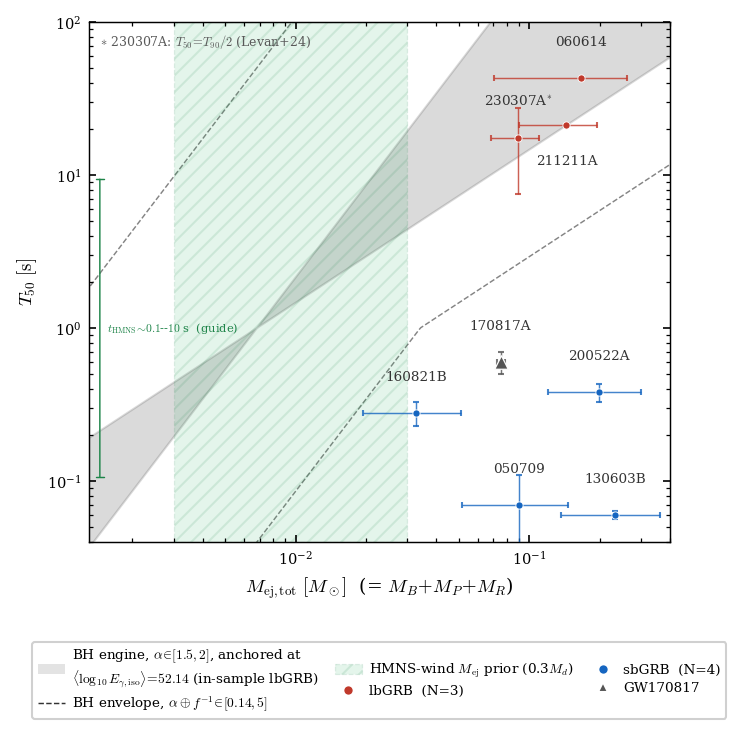

In [3]:
CLASS_STYLE = {
    # Colour-blind-safe palette.  The HMNS teal was moved to orange
    # (#d35400) in Fig. 2 to improve separation from the sbGRB blue under
    # protanopia simulation; the per-class dots below stay blue/red/grey.
    "lb": {"color": "#c0392b", "marker": "o", "label": r"lbGRBs"},
    "sb": {"color": "#1565c0", "marker": "o", "label": r"sbGRBs"},
    "gw": {"color": "#555555", "marker": "^", "label": r"GW170817"},
}
COMPONENT_COLORS = {
    "R": "#c0392b",  # red / lanthanide-rich (disk-wind MHD)
    "P": "#7d3c98",  # purple / intermediate (disk-wind thermal)
    "B": "#1f78b4",  # blue / lanthanide-poor (DYNAMICAL; not disk-wind)
}


# Per-event label offsets relative to each marker, as
# (dx_pts, dy_pts, ha).  Labels sit 14 pt directly above each marker,
# except 211211A which is dropped 14 pt below to keep its label clear
# of the 060614 / 230307A* labels in the upper-mid lbGRB cluster.
EVENT_LABEL_OFFSETS_F1 = {
    "050709":  (0,  14, "center"),
    "060614":  (0,  14, "center"),
    "130603B": (0,  14, "center"),
    "160821B": (0,  14, "center"),
    "170817A": (0,  14, "center"),
    "200522A": (0,  14, "center"),
    "211211A": (0, -14, "center"),
    "230307A": (0,  14, "center"),
}
DEFAULT_LABEL_OFFSET = (0, 14, "center")
LABEL_TEXT = {"230307A": r"230307A$^{\ast}$"}


def plot_fig1(df, posteriors, savepath_pdf,
              E_iso_ref=None, alpha_range=(1.5, 2.0),
              f_range=GOTTLIEB25_F_RANGE):
    """Duration-ejecta plane with population BH band and HMNS-wind M_ej strip.

    ``E_iso_ref=None`` (default) computes the geometric mean of the lbGRB
    ``E_iso`` values in this sample for the population band.  ``posteriors``
    is kept in the signature for API symmetry with ``plot_fig1_composition``;
    the per-event component-mass medians are no longer drawn on this panel.
    """
    missing = set(df["name"]) - set(EVENT_LABEL_OFFSETS_F1)
    assert not missing, (
        f"EVENT_LABEL_OFFSETS_F1 missing entries for: {sorted(missing)}"
    )

    fig, ax = plt.subplots(figsize=(5.0, 4.5))

    if E_iso_ref is None:
        lb = df[df.grb_class == "lb"]
        E_iso_ref = float(10.0 ** np.log10(lb["E_iso_erg"]).mean())
        E_iso_ref_source = "in-sample lbGRB geomean"
    else:
        E_iso_ref_source = "user-specified"

    # Population BH band -- uses the in-sample lbGRB E_iso as its anchor.
    # Solves eq11 for T_50 given M_ej on a grid so the band runs along
    # the T_50 axis at a given (E_iso, alpha, f_inv) corner.
    M_grid = np.logspace(-3.5, 0.0, 400)
    norm = 1e-3 * E_iso_ref / 2e51
    # alpha-only envelope (f_inv = 1): T50 = (M/norm)^{1/(alpha-1)}
    inv_a2 = M_grid / norm
    inv_a15 = (M_grid / norm) ** 2.0
    band_alpha_lo = np.minimum(inv_a2, inv_a15)
    band_alpha_hi = np.maximum(inv_a2, inv_a15)
    ax.fill_between(M_grid, band_alpha_lo, band_alpha_hi,
                    color="0.2", alpha=0.18, zorder=1)

    finv_lo, finv_hi = 0.1 / f_range[1], 0.1 / f_range[0]
    corners_lo = []
    for a in alpha_range:
        for fi in (finv_lo, finv_hi):
            inv_full = (M_grid / (1e-3 * fi * E_iso_ref / 2e51)) ** (1.0 / (a - 1.0))
            corners_lo.append(inv_full)
    corners = np.stack(corners_lo, axis=0)
    env_lo, env_hi = corners.min(axis=0), corners.max(axis=0)
    ax.plot(M_grid, env_lo, ls="--", lw=0.7, color="0.2", alpha=0.6,
            zorder=1)
    ax.plot(M_grid, env_hi, ls="--", lw=0.7, color="0.2", alpha=0.6,
            zorder=1)

    # HMNS-wind M_ej prior: vertical strip (not box).  The T_50 extent of
    # the old box was an editorial overlay; neither Gottlieb+25 §3.1 nor
    # Lippuner+17 / Fujibayashi+18 / Metzger+19 claim the HMNS engine
    # predicts T_50.  A narrow bracket at the left edge marks the
    # HMNS spin-down / viscous timescale as a *guide* only.
    hmns_lo, hmns_hi = hmns_wind_band()
    ax.axvspan(hmns_lo, hmns_hi, facecolor="#27ae60", alpha=0.12,
               edgecolor="#1e8449", linewidth=0.6, linestyle="--",
               hatch="///", zorder=1)
    t_lo, t_hi = GOTTLIEB25_T_HMNS_RANGE
    # t_HMNS bracket: small vertical line at the very left of the axes.
    ax.annotate("", xy=(1.45e-3, t_lo), xytext=(1.45e-3, t_hi),
                arrowprops=dict(arrowstyle="|-|,widthA=0.25,widthB=0.25",
                                lw=0.7, color="#1e8449"),
                zorder=3)
    ax.text(1.55e-3, np.sqrt(t_lo * t_hi),
            r"$t_{\rm HMNS}\!\sim\!0.1$--$10$ s  (guide)",
            fontsize=5.5, color="#1e8449", ha="left", va="center",
            zorder=3)

    for _, row in df.iterrows():
        cls = "gw" if row.grb_class == "gw" else row.grb_class
        style = CLASS_STYLE[cls]
        x = row.M_tot_med
        y = row.T50_s
        x_err = np.array([[row.M_tot_lo], [row.M_tot_hi]])
        y_err = np.array([[row.T50_err_s], [row.T50_err_s]])
        ax.errorbar(x, y, xerr=x_err, yerr=y_err,
                    fmt="none", ecolor=style["color"], elinewidth=0.7,
                    capsize=1.5, alpha=0.8, zorder=4)
        lab_dx, lab_dy, lab_ha = EVENT_LABEL_OFFSETS_F1.get(
            row["name"], DEFAULT_LABEL_OFFSET)
        if cls == "gw":
            ax.scatter(x, y, s=42, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.6, zorder=5)
        else:
            ax.scatter(x, y, s=12, marker=style["marker"],
                       facecolor=style["color"], edgecolor="white",
                       linewidth=0.4, zorder=5)
        v_align = "bottom" if lab_dy >= 0 else "top"
        ax.annotate(LABEL_TEXT.get(row["name"], row["name"]),
                    xy=(x, y),
                    xytext=(lab_dx, lab_dy), textcoords="offset points",
                    ha=lab_ha, va=v_align,
                    fontsize=6.5, color="0.2", zorder=7)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1.3e-3, 0.4)
    ax.set_ylim(0.04, 100)
    ax.set_xlabel(r"$M_{\rm ej,tot}\ [M_\odot]$  (= $M_B\!+\!M_P\!+\!M_R$)")
    ax.set_ylabel(r"$T_{50}\ [{\rm s}]$")

    n_lb = int((df.grb_class == "lb").sum())
    n_sb = int((df.grb_class == "sb").sum())
    handles = [
        mpl.patches.Patch(
            facecolor="0.4", alpha=0.18,
            label=(r"BH engine, $\alpha\!\in\![1.5,2]$, anchored at"
                   "\n"
                   rf"$\langle\log_{{10}}E_{{\gamma,\rm iso}}\rangle"
                   rf"\!=\!{np.log10(E_iso_ref):.2f}$ (in-sample lbGRB)")),
        plt.Line2D([0], [0], color="0.2", lw=0.7, ls="--",
                   label=r"BH envelope, $\alpha\oplus f^{-1}\!\in\![0.14,5]$"),
        mpl.patches.Patch(facecolor="#27ae60", alpha=0.12,
                          edgecolor="#1e8449", linewidth=0.6,
                          linestyle="--", hatch="///",
                          label=r"HMNS-wind $M_{\rm ej}$ prior (0.3$M_d$)"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=5,
                   label=f"lbGRB  (N={n_lb})"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=5,
                   label=f"sbGRB  (N={n_sb})"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=5,
                   label="GW170817"),
    ]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              fontsize=6.5,
              borderpad=0.4, handletextpad=0.5, labelspacing=0.35,
              ncol=3, columnspacing=1.2,
              frameon=True, framealpha=0.92)

    # Footnote in the upper-left white space: the bottom-right is crowded
    # by the 130603B marker and 050709 / 200522A errorbars at the zoomed
    # axis limits, so the 230307A caveat moves into the empty quadrant.
    ax.text(
        0.02, 0.98,
        r"$\ast$ 230307A: $T_{50}\!=\!T_{90}/2$ (Levan+24)",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=6.0, color="0.35",
    )

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


fig1 = plot_fig1(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig1.pdf"),
)
plt.show()


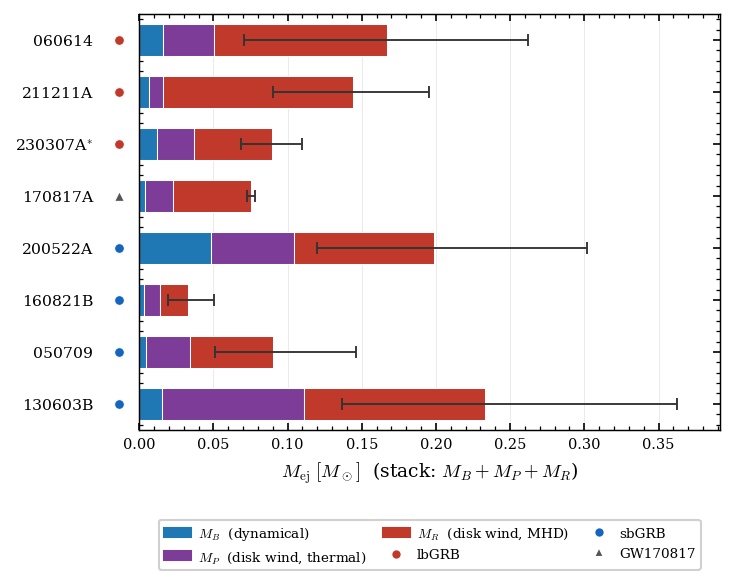

In [4]:
def plot_fig1_composition(df, posteriors, savepath_pdf):
    """Per-event ejecta composition split into M_B (dynamical),
    M_P (intermediate disk wind), and M_R (lanthanide-rich disk wind),
    drawn as horizontal stacked bars.  Companion to ``plot_fig1`` so
    the duration-mass plane there stays uncluttered.

    Segments are the posterior-median component masses (Rastinejad et
    al. 2024, ApJ 979, 190, Table 3), rescaled by the common per-event
    factor ``median(M_tot) / (median(M_B)+median(M_P)+median(M_R))`` so
    the stack tip lands exactly on the centre of the M_tot error bar.
    Without that rescaling the two drift apart by one to two percent
    because, for asymmetric split-normal marginals, the median of a sum
    is not the sum of component medians.  The composition ratio
    M_B : M_P : M_R is preserved.  Whiskers show the 16-84 percentile
    range of the sample-by-sample sum M_tot = M_B + M_P + M_R, the
    68% credible interval on the total ejecta mass and not on any
    single component.  Colour convention: B blue, P purple, R red
    (matches the COMPONENT_COLORS palette).
    """
    order_lb = df[df.grb_class == "lb"].sort_values(
        "T50_s", ascending=False)["name"].tolist()
    order_gw = df[df.grb_class == "gw"]["name"].tolist()
    order_sb = df[df.grb_class == "sb"].sort_values(
        "T50_s", ascending=False)["name"].tolist()
    order = order_lb + order_gw + order_sb

    fig, ax = plt.subplots(figsize=(5.0, 3.6))
    y_positions = np.arange(len(order))[::-1]
    bar_h = 0.62

    marker_trans = mpl.transforms.blended_transform_factory(
        ax.transAxes, ax.transData,
    )

    for y, name in zip(y_positions, order):
        post = posteriors[name]
        m_tot_samples = post["M_tot"]
        m_tot_med = float(np.median(m_tot_samples))
        m_tot_lo  = m_tot_med - float(np.percentile(m_tot_samples, 16))
        m_tot_hi  = float(np.percentile(m_tot_samples, 84)) - m_tot_med

        # Component medians rescaled so the stack sums to median(M_tot),
        # placing the bar tip exactly on the error-bar centre.  See
        # docstring for why this matters.
        m_b_med = float(np.median(post["M_B"]))
        m_p_med = float(np.median(post["M_P"]))
        m_r_med = float(np.median(post["M_R"]))
        meds_sum = m_b_med + m_p_med + m_r_med
        scale   = m_tot_med / meds_sum if meds_sum > 0 else 1.0
        m_b = m_b_med * scale
        m_p = m_p_med * scale
        m_r = m_r_med * scale

        ax.barh(y, m_b, height=bar_h, color=COMPONENT_COLORS["B"],
                edgecolor="white", linewidth=0.5, zorder=2)
        ax.barh(y, m_p, left=m_b, height=bar_h,
                color=COMPONENT_COLORS["P"], edgecolor="white",
                linewidth=0.5, zorder=2)
        ax.barh(y, m_r, left=m_b + m_p, height=bar_h,
                color=COMPONENT_COLORS["R"], edgecolor="white",
                linewidth=0.5, zorder=2)

        # Error bar drawn on top of the stack (zorder=6) because the
        # left whisker crosses the bar.  Dark grey is visible against
        # both the red M_R segment and the white gridlines; a path
        # effect stroke cut an ugly gap through the bar, so no stroke.
        ax.errorbar(m_tot_med, y, xerr=[[m_tot_lo], [m_tot_hi]],
                    fmt="none", ecolor="0.2", elinewidth=0.9,
                    capsize=2.8, capthick=0.9, zorder=6)

        # Class marker lives in axes-fraction x (so its offset from the
        # y-axis does not rescale with x_max) and in data y.  Pairing it
        # with a wider tick-label pad below keeps the glyph from
        # overlapping the event-name text.
        row = df[df["name"] == name].iloc[0]
        cls_color  = CLASS_STYLE[row.grb_class]["color"]
        cls_marker = CLASS_STYLE[row.grb_class]["marker"]
        ax.scatter(-0.035, y, marker=cls_marker, s=22,
                   facecolor=cls_color, edgecolor="white",
                   linewidth=0.5, clip_on=False, zorder=5,
                   transform=marker_trans)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([LABEL_TEXT.get(n, n) for n in order], fontsize=7.5)
    ax.tick_params(axis="y", left=False, pad=22)
    ax.set_xlabel(r"$M_{\rm ej}\ [M_\odot]$"
                  r"  (stack: $M_B + M_P + M_R$)")

    # x range covers every +1 sigma whisker with a small margin so the
    # 060614 and 200522A caps do not clip, which the previous
    # median-based limit allowed.
    x_max_hi = max(
        float(np.percentile(posteriors[n]["M_tot"], 84)) for n in order
    )
    ax.set_xlim(0.0, x_max_hi * 1.08)
    ax.set_ylim(-0.5, len(order) - 0.5)
    ax.grid(True, axis="x", alpha=0.3, linewidth=0.4)
    ax.set_axisbelow(True)

    handles = [
        mpl.patches.Patch(color=COMPONENT_COLORS["B"],
                          label=r"$M_B$  (dynamical)"),
        mpl.patches.Patch(color=COMPONENT_COLORS["P"],
                          label=r"$M_P$  (disk wind, thermal)"),
        mpl.patches.Patch(color=COMPONENT_COLORS["R"],
                          label=r"$M_R$  (disk wind, MHD)"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=5,
                   label="lbGRB"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=5,
                   label="sbGRB"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=5,
                   label="GW170817"),
    ]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.20),
              fontsize=6.5, ncol=3, columnspacing=1.2,
              borderpad=0.4, handletextpad=0.5,
              frameon=True, framealpha=0.92)

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


fig1b = plot_fig1_composition(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig1_composition.pdf"),
)
plt.show()

### Figure 1

| Element | Source |
| --- | --- |
| BH grey band ($\alpha \in [1.5,2]$) | Gottlieb+25 Eq. 11 ([arXiv:2411.13657](https://arxiv.org/abs/2411.13657)) |
| BH dashed envelope ($f^{-1} \in [0.14,5]$) | $f = \varepsilon_\gamma f_b$, $f_b \in [0.01,0.11]$ (Berger 2014, ARA&A 52, 43); $\varepsilon_\gamma \in [0.15,0.5]$ (Beniamini & Granot 2015) |
| BH band centre $E_{\gamma,\rm iso}$ | in-sample lbGRB geomean (printed in figure footnote) |
| HMNS box, $x$-axis | $0.3\,M_d$, $M_d \in [0.01,0.10]\,M_\odot$ (Krüger & Foucart 2020, [arXiv:2002.07728](https://arxiv.org/abs/2002.07728); Gottlieb+25 §3.1; Radice+18, [arXiv:1809.11163](https://arxiv.org/abs/1809.11163)) |
| HMNS box, $y$-axis | $t_{\rm HMNS} \in [0.1,10]\,$s, magnetar spin-down / viscous timescale (Lippuner+17; Fujibayashi+18; Metzger 2019) |
| Donut wedges $M_{\rm ej,R/P/B}$ | Rastinejad+24, [ApJ 979, 190](https://arxiv.org/abs/2306.14947), Table 3 medians |
| Class colours | lbGRB `#c0392b`, sbGRB `#1565c0`, GW170817 `#555555` (colour-blind safe, protanopia-tested) |
| 230307A asterisk | $T_{50} = T_{90}/2 = 17.5\,$s (Levan+24, [Nature 626, 737](https://arxiv.org/abs/2307.02098)); $\pm 10\,$s brackets main-pulse vs full-$T_{90}$ |

sbGRB events should be read against their own per-event tracks, not the lb-anchored grey band. An sb-class population band would sit about 1.5 dex lower since the sbGRB $E_{\gamma,\rm iso}$ geomean is 30 to 1000 times below the lbGRBs.

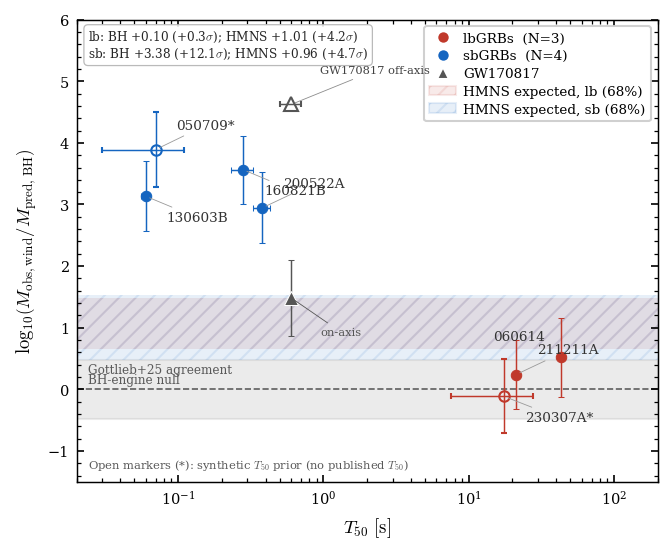


Engine null hypothesis test (M_obs,wind = M_P + M_R)
----------------------------------------------------
  lbGRBs:  <log10 R_BH>   = +0.17 (N=3)
            BH DL:        mu = +0.10 +/- 0.37, tau = 0.00,  offset = +0.3sigma
            BH unweighted:se = 0.46,                    offset = +0.4sigma
            BH Cochran Q p-value = 0.863
            HMNS DL:      mu = +1.01 +/- 0.24, tau = 0.00,  offset = +4.2sigma
            log10 B10(HMNS/BH) = -3.3
  sbGRBs:  <log10 R_BH>   = +3.38 (N=4)
            BH DL:        mu = +3.38 +/- 0.28, tau = 0.00,  offset = +12.1sigma
            BH unweighted:se = 0.28,                    offset = +12.0sigma
            BH Cochran Q p-value = 0.651
            HMNS DL:      mu = +0.96 +/- 0.20, tau = 0.00,  offset = +4.7sigma
            log10 B10(HMNS/BH) = +27.1

  Notes:
  - log10 B10 above uses a Gaussian-in-log Laplace approximation
    to the marginal evidence; treat magnitudes as order-of-magnitude
    indicators rather than calibrated evid

In [5]:
from scipy import stats


# ---------------------------------------------------------------------------
# Per-event log-ratio helpers.  The residual is evaluated on the disk-wind
# mass M_wind = M_P + M_R (Metzger 2019 mapping) because both engines
# (Gottlieb+25 Eq. 11 BH and f_wind * M_d HMNS) predict disk-wind ejecta
# only.  Using M_tot, as earlier drafts did, inflated the sb residual by
# including the dynamical M_B component that neither engine claims.
#
# The HMNS prediction draws BOTH M_d (log-uniform, KF2020 / Radice+18)
# AND f_wind (log-uniform on GOTTLIEB25_WIND_FRAC_RANGE = [0.2, 0.4],
# Radice+18 GRMHD scatter); the older f_wind = 0.3 point value hid a
# real systematic in the HMNS bars.
# ---------------------------------------------------------------------------

def _mc_log_ratio(row, posteriors, n=10_000, seed=None,
                  alpha_range=(1.5, 2.0), obs_key="M_wind"):
    """Joint posterior on log10(M_obs / M_pred_BH) for one event."""
    rng = np.random.default_rng(seed)
    pred = predict_bh_mc(row, n=n, rng=rng, alpha_range=alpha_range)
    obs_pool = posteriors[row["name"]][obs_key]
    obs = rng.choice(obs_pool, size=n, replace=True)
    obs = np.clip(obs, 1e-8, None)
    pred = np.clip(pred, 1e-30, None)
    return np.log10(obs / pred)


def _hmns_log_ratio(row, posteriors, n=10_000, seed=None,
                    M_disk_range=GOTTLIEB25_DISK_RANGE,
                    wind_frac_range=GOTTLIEB25_WIND_FRAC_RANGE,
                    obs_key="M_wind"):
    """log10(M_obs / M_HMNS) drawn from the joint posterior with log-uniform
    M_d AND log-uniform f_wind.  The BNS post-merger disk-mass distribution
    from KF2020 / Radice+18 NR sweeps is closer to log-flat than linear-flat
    across [0.01, 0.10] M_sun; a linear prior over-weights the upper octave.
    f_wind is drawn log-uniformly on [0.2, 0.4] (Radice+18 Table 2 GRMHD
    range) instead of fixed at 0.3.
    """
    rng = np.random.default_rng(seed)
    obs_pool = posteriors[row["name"]][obs_key]
    obs = rng.choice(obs_pool, size=n, replace=True)
    md = 10.0 ** rng.uniform(np.log10(M_disk_range[0]),
                              np.log10(M_disk_range[1]), size=n)
    fw = 10.0 ** rng.uniform(np.log10(wind_frac_range[0]),
                              np.log10(wind_frac_range[1]), size=n)
    pred = fw * md
    return np.log10(np.clip(obs, 1e-8, None) / np.clip(pred, 1e-8, None))


def wind_frac_apply(rng, n, M_disk_range=GOTTLIEB25_DISK_RANGE,
                    wind_frac_range=GOTTLIEB25_WIND_FRAC_RANGE):
    """Draw HMNS-engine M_ej = f_wind * M_d with both factors log-uniform.

    f_wind range matches Radice+18 Table 2 (arXiv:1809.11163) GRMHD
    scatter; M_d range matches Kruger & Foucart 2020 Eq. 4.
    """
    md = 10.0 ** rng.uniform(np.log10(M_disk_range[0]),
                              np.log10(M_disk_range[1]), size=n)
    fw = 10.0 ** rng.uniform(np.log10(wind_frac_range[0]),
                              np.log10(wind_frac_range[1]), size=n)
    return fw * md


def bayes_factor_bh_vs_hmns(rows, posteriors, n=10_000, seed=42,
                             alpha_range=(1.5, 2.0), obs_key="M_wind"):
    """Gaussian-in-log Bayes factor B10 = P(D|HMNS)/P(D|BH).  Returns
    log10 B10 summed across events (events assumed independent).

    This is a Laplace-style approximation: the wide log-uniform M_d and
    f priors and the per-event observed posteriors are reduced to
    (mean, std) pairs and combined as Gaussians.  The tails of those
    priors are under-represented, so |log10 B10| can be inflated.  Treat
    the returned magnitude as an order-of-magnitude indicator; a full
    marginal evidence requires per-sample likelihood evaluation (e.g.
    KDE on the prior draws)."""
    log10_B = 0.0
    rng_seq = np.random.SeedSequence(seed)
    for _, row in rows.iterrows():
        rng_bh   = np.random.default_rng(rng_seq.spawn(1)[0])
        rng_hmns = np.random.default_rng(rng_seq.spawn(1)[0])
        pred_bh   = np.log10(np.clip(
            predict_bh_mc(row, n=n, rng=rng_bh, alpha_range=alpha_range),
            1e-30, None))
        pred_hmns = np.log10(wind_frac_apply(rng_hmns, n))
        obs_log   = np.log10(np.clip(posteriors[row["name"]][obs_key],
                                     1e-8, None))
        obs_mean = np.mean(obs_log)
        obs_std  = np.std(obs_log) + 1e-3
        mu_bh,   sig_bh   = pred_bh.mean(),   pred_bh.std()
        mu_hmns, sig_hmns = pred_hmns.mean(), pred_hmns.std()
        sig_bh_eff   = np.sqrt(sig_bh**2   + obs_std**2)
        sig_hmns_eff = np.sqrt(sig_hmns**2 + obs_std**2)
        log_L_bh   = stats.norm.logpdf(obs_mean, mu_bh,   sig_bh_eff)
        log_L_hmns = stats.norm.logpdf(obs_mean, mu_hmns, sig_hmns_eff)
        log10_B += (log_L_hmns - log_L_bh) / np.log(10.0)
    return log10_B


def hierarchical_log_ratio_test(per_event_means, per_event_stds):
    """Random-effects meta-analysis on per-event mean log-ratios.

    Uses the DerSimonian & Laird (1986, Controlled Clin. Trials 7, 177)
    moment estimator of the between-event variance tau^2.  This is the
    standard tool for the N=3-4 meta-analytic regime where Bayesian
    hierarchical models with weakly-informative priors collapse to
    fixed-effects.

    Model: x_i ~ N(mu_i, s_i^2) with mu_i ~ N(mu, tau^2).  Combined SE
    on mu is SE(mu) = 1 / sqrt(sum w_i) with w_i = 1/(s_i^2 + tau^2).
    When tau^2 = 0 this reduces to inverse-variance-weighted
    fixed-effects; when intrinsic scatter dominates it approaches
    sd(x_i) / sqrt(N).
    """
    x = np.asarray(per_event_means, dtype=float)
    s = np.asarray(per_event_stds, dtype=float)
    s = np.maximum(s, 1e-3)
    n_events = len(x)
    if n_events < 2:
        return {"mu_mean": float(np.mean(x)),
                "mu_se": float(s[0]) if n_events == 1 else float("nan"),
                "tau_med": 0.0, "Q": 0.0,
                "Q_pvalue": float("nan"), "n": n_events}

    w_fe = 1.0 / (s ** 2)
    x_fe = float(np.sum(w_fe * x) / np.sum(w_fe))
    Q = float(np.sum(w_fe * (x - x_fe) ** 2))
    df = n_events - 1
    c = float(np.sum(w_fe) - np.sum(w_fe ** 2) / np.sum(w_fe))
    tau2_dl = max(0.0, (Q - df) / c) if c > 0 else 0.0

    w_re = 1.0 / (s ** 2 + tau2_dl)
    mu = float(np.sum(w_re * x) / np.sum(w_re))
    se = float(1.0 / np.sqrt(np.sum(w_re)))
    return {
        "mu_mean":  mu,
        "mu_se":    se,
        "tau_med":  float(np.sqrt(tau2_dl)),
        "Q":        Q,
        "Q_pvalue": float(stats.chi2.sf(Q, df)) if df > 0 else float("nan"),
        "n":        n_events,
    }


# ---------------------------------------------------------------------------
# Fig. 2 and its alpha-sensitivity twin.
# ---------------------------------------------------------------------------
LABEL_OFFSETS_F2 = {
    "050709":  (10,  10, "left"),
    "130603B": (10, -12, "left"),
    "160821B": (10, -12, "left"),
    "200522A": (10,  10, "left"),
    "211211A": (10,  10, "left"),
    "230307A": (10, -12, "left"),
    "060614":  (-8,   8, "right"),
    "170817A": (8,   -8, "left"),
}

# HMNS-engine prediction is T_50-independent (Gottlieb+25 §3.1), so the
# per-event orange + crosses used in earlier drafts implied a non-existent
# T_50 axis.  Fig. 2 now renders one pooled subclass-level horizontal
# y-band instead; HMNS_CROSS_JITTER is retired.

# Mooley et al. 2018 (Nature 561, 355) and Ghirlanda et al. 2019
# (Science 363, 968) structured-jet reconstructions place GW170817's
# on-axis-equivalent isotropic energy near 1e52 erg, three to four
# orders of magnitude brighter than the 6e48 erg observed at our
# viewing angle.  The on-axis value is the apples-to-apples input to
# Eq. (11); the off-axis value is a model misapplication.
GW170817_E_ISO_ONAXIS_ERG = 1e52
GW170817_E_ISO_ONAXIS_ERR = 0.6e52


def _label_assert(df, offsets_dict, dict_name):
    missing = set(df["name"]) - set(offsets_dict)
    extra   = set(offsets_dict) - set(df["name"])
    assert not missing and not extra, (
        f"{dict_name} and df['name'] disagree; missing={sorted(missing)}, "
        f"extra={sorted(extra)}"
    )


def _legend_handles_fig2(df):
    """Construct the standard Fig. 2 legend handle list.

    Pulled out so plot_fig2 and plot_fig2_combined render the same
    legend without duplicating handle definitions.
    """
    n_lb = int((df.grb_class == "lb").sum())
    n_sb = int((df.grb_class == "sb").sum())
    return [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["lb"]["color"], markersize=6,
                   label=f"lbGRBs  (N={n_lb})"),
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=CLASS_STYLE["sb"]["color"], markersize=6,
                   label=f"sbGRBs  (N={n_sb})"),
        plt.Line2D([0], [0], marker="^", color="w",
                   markerfacecolor=CLASS_STYLE["gw"]["color"], markersize=6,
                   label="GW170817"),
        mpl.patches.Patch(facecolor=CLASS_STYLE["lb"]["color"], alpha=0.10,
                          edgecolor=CLASS_STYLE["lb"]["color"], hatch="///",
                          label="HMNS expected, lb (68%)"),
        mpl.patches.Patch(facecolor=CLASS_STYLE["sb"]["color"], alpha=0.10,
                          edgecolor=CLASS_STYLE["sb"]["color"], hatch="///",
                          label="HMNS expected, sb (68%)"),
    ]


def _render_residual_panel(ax, df, posteriors, *, n, seed, alpha_range,
                           show_onaxis_gw=True, stat_block=None,
                           title_suffix="", panel_title=None,
                           show_ylabel=True, show_legend=True,
                           show_synth_caption=True,
                           show_band_labels=True):
    """Draw one log10(M_obs,wind / M_pred_BH) panel into ``ax``.

    Single source of truth for the per-axis layout, used both by the
    single-panel ``plot_fig2`` and the side-by-side ``plot_fig2_combined``.
    Flags suppress redundant elements when this axis shares its y-axis
    or its synthetic-T50 caption with a sibling panel.
    """
    rng_seq = np.random.SeedSequence(seed)

    ax.axhspan(np.log10(1.0 / 3.0), np.log10(3.0),
               color="0.7", alpha=0.25,
               label=r"Gottlieb+25 agreement ($\times\!1/3$--$3$)")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.6)
    if show_band_labels:
        ax.text(0.024, np.log10(3.0) - 0.05, "Gottlieb+25 agreement",
                fontsize=5.8, color="0.35", ha="left", va="top")
        ax.text(0.024, 0.05, "BH-engine null",
                fontsize=5.8, color="0.35", ha="left", va="bottom")

    # Pooled per-subclass HMNS-engine residual y-bands.  HMNS prediction
    # is T_50-independent (Gottlieb+25 §3.1), so the residual lives on
    # the y-axis only.  Each band shades the [16, 84] percentile of
    # log10(M_obs / M_HMNS) pooled across every event in that subclass,
    # marginalising over log-uniform M_d in [0.01, 0.10] M_sun and
    # log-uniform f_wind in [0.2, 0.4].  Independent of alpha_range.
    hmns_band_seed = np.random.SeedSequence(seed + 99991)
    for cls in ("lb", "sb"):
        cls_rows = df[df.grb_class == cls]
        if len(cls_rows) == 0:
            continue
        pool = np.concatenate([
            _hmns_log_ratio(row, posteriors, n=n,
                            seed=hmns_band_seed.spawn(1)[0])
            for _, row in cls_rows.iterrows()
        ])
        y_lo, y_hi = np.percentile(pool, [16, 84])
        ax.axhspan(y_lo, y_hi,
                   facecolor=CLASS_STYLE[cls]["color"], alpha=0.10,
                   edgecolor=CLASS_STYLE[cls]["color"], linewidth=0.0,
                   hatch="///", zorder=1)

    for _, row in df.iterrows():
        cls = row.grb_class
        style = CLASS_STYLE[cls]
        seed_i = rng_seq.spawn(1)[0]
        log_R_bh = _mc_log_ratio(row, posteriors, n=n, seed=seed_i,
                                 alpha_range=alpha_range)
        med = np.median(log_R_bh)
        lo  = med - np.percentile(log_R_bh, 16)
        hi  = np.percentile(log_R_bh, 84) - med
        synthetic_t50 = row["name"] in T50_PRIOR_OVERRIDES
        if cls == "gw":
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=None,
                        fmt=style["marker"], ms=7,
                        mfc="none", mec=style["color"],
                        ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mew=1.0,
                        zorder=5)
            ax.annotate(
                "GW170817 off-axis",
                xy=(row.T50_s, med),
                xytext=(14, 14), textcoords="offset points",
                ha="left", va="bottom",
                fontsize=5.5, color="0.25", zorder=6,
                arrowprops=dict(arrowstyle="-", lw=0.4, color="0.55",
                                shrinkA=0.0, shrinkB=2.0))
            if show_onaxis_gw:
                row_on = row.copy()
                row_on.E_iso_erg     = GW170817_E_ISO_ONAXIS_ERG
                row_on.E_iso_err_erg = GW170817_E_ISO_ONAXIS_ERR
                log_R_bh_on = _mc_log_ratio(row_on, posteriors, n=n,
                                            seed=rng_seq.spawn(1)[0],
                                            alpha_range=alpha_range)
                med_on = np.median(log_R_bh_on)
                lo_on  = med_on - np.percentile(log_R_bh_on, 16)
                hi_on  = np.percentile(log_R_bh_on, 84) - med_on
                ax.errorbar(row.T50_s, med_on,
                            yerr=[[lo_on], [hi_on]],
                            fmt=style["marker"], ms=7,
                            color=style["color"],
                            ecolor=style["color"],
                            elinewidth=0.7, capsize=1.5, mew=0.5,
                            mec="white", zorder=5)
                ax.annotate(
                    "on-axis",
                    xy=(row.T50_s, med_on),
                    xytext=(14, -14), textcoords="offset points",
                    ha="left", va="top",
                    fontsize=5.5, color=style["color"], zorder=6,
                    arrowprops=dict(arrowstyle="-", lw=0.4,
                                    color=style["color"],
                                    shrinkA=0.0, shrinkB=2.0))
        else:
            mfc = "none" if synthetic_t50 else style["color"]
            mec = style["color"]
            mew = 1.0 if synthetic_t50 else 0.5
            ax.errorbar(row.T50_s, med,
                        xerr=[[row.T50_err_s], [row.T50_err_s]],
                        yerr=[[lo], [hi]],
                        fmt=style["marker"], ms=5,
                        mfc=mfc, mec=mec, color=style["color"],
                        ecolor=style["color"],
                        elinewidth=0.7, capsize=1.5, mew=mew,
                        zorder=5)
            dx, dy, ha = LABEL_OFFSETS_F2.get(row["name"], (8, -3, "left"))
            arrow_kwargs = (
                dict(arrowprops=dict(arrowstyle="-", lw=0.4, color="0.6",
                                     shrinkA=0.0, shrinkB=2.0))
                if max(abs(dx), abs(dy)) >= 10 else {}
            )
            label_text = row["name"] + ("*" if synthetic_t50 else "")
            ax.annotate(label_text, xy=(row.T50_s, med),
                        xytext=(dx, dy), textcoords="offset points",
                        ha=ha,
                        fontsize=6.5, color="0.2", zorder=6,
                        **arrow_kwargs)

    ax.set_xscale("log")
    ax.set_xlim(0.02, 200)
    ax.set_ylim(-1.5, 6.0)
    ax.set_xlabel(r"$T_{50}\ [{\rm s}]$")
    if show_ylabel:
        ax.set_ylabel(
            r"$\log_{10}\!\left(M_{\rm obs,wind}/M_{\rm pred,\,BH}\right)$"
        )

    if panel_title:
        ax.set_title(panel_title, fontsize=8, pad=4)

    if show_legend:
        ax.legend(handles=_legend_handles_fig2(df), loc="upper right",
                  fontsize=6.5, borderpad=0.4, handletextpad=0.5,
                  labelspacing=0.35, framealpha=0.92)

    if stat_block:
        ax.text(0.02, 0.98, stat_block,
                transform=ax.transAxes, ha="left", va="top",
                fontsize=5.8, color="0.15",
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor="white", edgecolor="0.7",
                          linewidth=0.6, alpha=0.9))

    if show_synth_caption:
        ax.text(0.02, 0.02,
                "Open markers (*): synthetic $T_{50}$ prior "
                "(no published $T_{50}$)",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=5.5, color="0.35")

    if title_suffix:
        ax.text(0.98, 0.02, title_suffix,
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=6.0, color="0.3", style="italic")


def plot_fig2(df, posteriors, savepath_pdf, n=10_000, seed=20260417,
              alpha_range=(1.5, 2.0), show_onaxis_gw=True,
              stat_block=None, title_suffix=""):
    """Single-panel residual plot log10(M_obs,wind / M_pred_BH).

    Thin wrapper around ``_render_residual_panel`` that owns the figure
    canvas and disk output.  ``alpha_range`` is threaded through to the
    BH-engine MC so the Fig. 3 alpha=1 sensitivity panel can reuse this
    function.  ``stat_block`` places a pre-rendered multi-line string
    in the upper-left corner.
    """
    _label_assert(df, LABEL_OFFSETS_F2, "LABEL_OFFSETS_F2")
    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    _render_residual_panel(
        ax, df, posteriors,
        n=n, seed=seed, alpha_range=alpha_range,
        show_onaxis_gw=show_onaxis_gw,
        stat_block=stat_block, title_suffix=title_suffix,
    )
    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


def plot_fig2_combined(df, posteriors, savepath_pdf, n=10_000, seed=20260417,
                       alpha_range_left=(1.5, 2.0),
                       alpha_range_right=(1.0, 1.0),
                       show_onaxis_gw=True,
                       stat_blocks=None,
                       panel_titles=(
                           r"$\alpha\in[1.5,\,2.0]$ (Gottlieb+25 prior)",
                           r"$\alpha=1$ (no $T_{50}$ dependence)",
                       )):
    """Side-by-side Fig. 2 + Fig. 3 with a shared y-axis.

    Both panels share the y-axis range, the HMNS-engine bands (which
    are alpha-independent), and the GW170817 dual-marker rendering.
    The legend lives on the right panel only; the synthetic-T_50
    caption is placed once at the bottom of the figure.

    ``stat_blocks`` is an optional 2-tuple ``(left_block, right_block)``
    of pre-rendered multi-line strings (use the second return value of
    ``summarize_subclass`` for each alpha range).
    """
    _label_assert(df, LABEL_OFFSETS_F2, "LABEL_OFFSETS_F2")
    if stat_blocks is None:
        stat_blocks = (None, None)

    fig, (ax_l, ax_r) = plt.subplots(
        1, 2, figsize=(9.5, 4.0), sharey=True,
        gridspec_kw={"wspace": 0.05},
    )

    _render_residual_panel(
        ax_l, df, posteriors,
        n=n, seed=seed, alpha_range=alpha_range_left,
        show_onaxis_gw=show_onaxis_gw,
        stat_block=stat_blocks[0],
        panel_title=panel_titles[0],
        show_ylabel=True, show_legend=False,
        show_synth_caption=False, show_band_labels=True,
    )
    _render_residual_panel(
        ax_r, df, posteriors,
        n=n, seed=seed + 1, alpha_range=alpha_range_right,
        show_onaxis_gw=show_onaxis_gw,
        stat_block=stat_blocks[1],
        panel_title=panel_titles[1],
        show_ylabel=False, show_legend=True,
        show_synth_caption=False, show_band_labels=False,
    )

    fig.text(0.5, 0.005,
             "Open markers (*): synthetic $T_{50}$ prior "
             "(no published $T_{50}$).  HMNS bands shared between panels.",
             ha="center", va="bottom", fontsize=6.0, color="0.35")

    fig.savefig(savepath_pdf)
    fig.savefig(savepath_pdf.replace(".pdf", ".png"), dpi=300)
    return fig


def summarize_subclass(df, posteriors, alpha_range=(1.5, 2.0),
                       n=10_000, seed=20260417):
    """Per-subclass DL random-effects test + unweighted-mean SE + Bayes factor.

    The "unweighted" SE here is sqrt(sum(s_i^2)) / N, the standard error
    of an unweighted mean of N independent Gaussian per-event posteriors.
    It is NOT the canonical inverse-variance-weighted fixed-effects SE
    (1 / sqrt(sum(1/s_i^2))); the DL random-effects path below is the
    inverse-variance-weighted estimator.
    """
    results = {}
    lines = []
    rng_seq = np.random.SeedSequence(seed + sum(map(ord, str(alpha_range))))
    for cls in ("lb", "sb"):
        rows = df[df.grb_class == cls]
        per_event_mean, per_event_std = [], []
        per_event_mean_h, per_event_std_h = [], []
        for _, row in rows.iterrows():
            arr_bh = _mc_log_ratio(row, posteriors, n=n,
                                   seed=rng_seq.spawn(1)[0],
                                   alpha_range=alpha_range)
            per_event_mean.append(float(np.mean(arr_bh)))
            per_event_std.append(float(np.std(arr_bh)))
            arr_h = _hmns_log_ratio(row, posteriors, n=n,
                                    seed=rng_seq.spawn(1)[0])
            per_event_mean_h.append(float(np.mean(arr_h)))
            per_event_std_h.append(float(np.std(arr_h)))
        per_event_mean = np.array(per_event_mean)
        per_event_std  = np.array(per_event_std)
        per_event_mean_h = np.array(per_event_mean_h)
        per_event_std_h  = np.array(per_event_std_h)
        unweighted_se = np.sqrt(np.sum(per_event_std ** 2)) / len(per_event_mean)
        hier   = hierarchical_log_ratio_test(per_event_mean,   per_event_std)
        hier_h = hierarchical_log_ratio_test(per_event_mean_h, per_event_std_h)
        log10_B = bayes_factor_bh_vs_hmns(
            rows, posteriors, n=n,
            seed=11000 + ord(cls[0]),
            alpha_range=alpha_range,
        )
        sigma_hier = hier["mu_mean"] / hier["mu_se"] if hier["mu_se"] > 0 else np.inf
        sigma_hier_h = (
            hier_h["mu_mean"] / hier_h["mu_se"] if hier_h["mu_se"] > 0 else np.inf
        )
        unweighted_sigma = (
            per_event_mean.mean() / unweighted_se if unweighted_se > 0 else np.inf
        )
        results[cls] = {
            "mean":             float(per_event_mean.mean()),
            "unweighted_se":    float(unweighted_se),
            "unweighted_sigma": float(unweighted_sigma),
            "hier_mu":          hier["mu_mean"],
            "hier_se":          hier["mu_se"],
            "hier_sigma":       float(sigma_hier),
            "tau":              hier["tau_med"],
            "Q_pvalue":         hier["Q_pvalue"],
            "log10_B":          float(log10_B),
            "N":                hier["n"],
            "hmns_mu":          hier_h["mu_mean"],
            "hmns_se":          hier_h["mu_se"],
            "hmns_sigma":       float(sigma_hier_h),
            "hmns_tau":         hier_h["tau_med"],
        }
        lab = "lb" if cls == "lb" else "sb"
        lines.append(
            f"{lab}: BH {hier['mu_mean']:+.2f} ({sigma_hier:+.1f}$\\sigma$); "
            f"HMNS {hier_h['mu_mean']:+.2f} ({sigma_hier_h:+.1f}$\\sigma$)"
        )
    return results, "\n".join(lines)


# Run the subclass test at the default alpha prior and render Fig. 2.
summary, stat_block = summarize_subclass(df, posteriors,
                                          alpha_range=(1.5, 2.0))

fig2 = plot_fig2(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig2.pdf"),
    alpha_range=(1.5, 2.0),
    stat_block=stat_block,
)
plt.show()


print("\nEngine null hypothesis test (M_obs,wind = M_P + M_R)")
print("----------------------------------------------------")
for cls, label in (("lb", "lbGRBs"), ("sb", "sbGRBs")):
    r = summary[cls]
    print(
        f"  {label:<6s}:  <log10 R_BH>   = {r['mean']:+.2f} (N={r['N']})\n"
        f"            BH DL:        mu = {r['hier_mu']:+.2f} +/- {r['hier_se']:.2f}, "
        f"tau = {r['tau']:.2f},  offset = {r['hier_sigma']:+.1f}sigma\n"
        f"            BH unweighted:se = {r['unweighted_se']:.2f},                    "
        f"offset = {r['unweighted_sigma']:+.1f}sigma\n"
        f"            BH Cochran Q p-value = {r['Q_pvalue']:.3f}\n"
        f"            HMNS DL:      mu = {r['hmns_mu']:+.2f} +/- {r['hmns_se']:.2f}, "
        f"tau = {r['hmns_tau']:.2f},  offset = {r['hmns_sigma']:+.1f}sigma\n"
        f"            log10 B10(HMNS/BH) = {r['log10_B']:+.1f}"
    )
print(
    "\n  Notes:"
    "\n  - log10 B10 above uses a Gaussian-in-log Laplace approximation"
    "\n    to the marginal evidence; treat magnitudes as order-of-magnitude"
    "\n    indicators rather than calibrated evidence ratios."
    "\n  - hier_sigma assumes per-event std >= 1e-3 in log10 units"
    "\n    (floor in hierarchical_log_ratio_test); tightening this floor"
    "\n    would inflate sigma."
    "\n  - HMNS-engine prediction draws f_wind log-uniformly on [0.2, 0.4]"
    "\n    (Radice+18 GRMHD scatter) and M_d log-uniformly on [0.01, 0.10]"
    "\n    M_sun (KF2020 Eq. 4)."
)


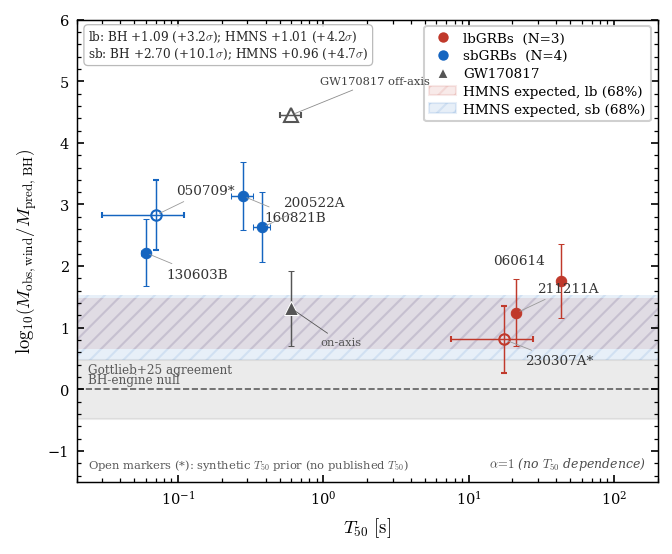


Alpha-sensitivity: residuals at alpha = 1
------------------------------------------
  lbGRBs:  <log10 R> = +1.23  mu = +1.09 +/- 0.34,  offset = +3.2sigma,  log10 B10(HMNS/BH) = -1.2
  sbGRBs:  <log10 R> = +2.70  mu = +2.70 +/- 0.27,  offset = +10.1sigma,  log10 B10(HMNS/BH) = +17.4


In [6]:
# Figure 3: alpha-sensitivity check.  Equation 11 has a T_50^{alpha-1}
# scaling; the default prior alpha in [1.5, 2] gives short events a
# smaller predicted M_ej by construction.  If the sbGRB residual survives
# at alpha = 1 (no T_50 dependence), the BH-engine rejection is robust
# to this prior choice.  If it collapses, the result is alpha-driven and
# the claim needs rephrasing.
summary_a1, stat_block_a1 = summarize_subclass(
    df, posteriors, alpha_range=(1.0, 1.0),
)
fig3 = plot_fig2(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig3.pdf"),
    alpha_range=(1.0, 1.0),
    stat_block=stat_block_a1,
    title_suffix=r"$\alpha\!=\!1$ (no $T_{50}$ dependence)",
)
plt.show()

print("\nAlpha-sensitivity: residuals at alpha = 1")
print("------------------------------------------")
for cls, label in (("lb", "lbGRBs"), ("sb", "sbGRBs")):
    r = summary_a1[cls]
    print(
        f"  {label:<6s}:  <log10 R> = {r['mean']:+.2f}  "
        f"mu = {r['hier_mu']:+.2f} +/- {r['hier_se']:.2f},  "
        f"offset = {r['hier_sigma']:+.1f}sigma,  "
        f"log10 B10(HMNS/BH) = {r['log10_B']:+.1f}"
    )


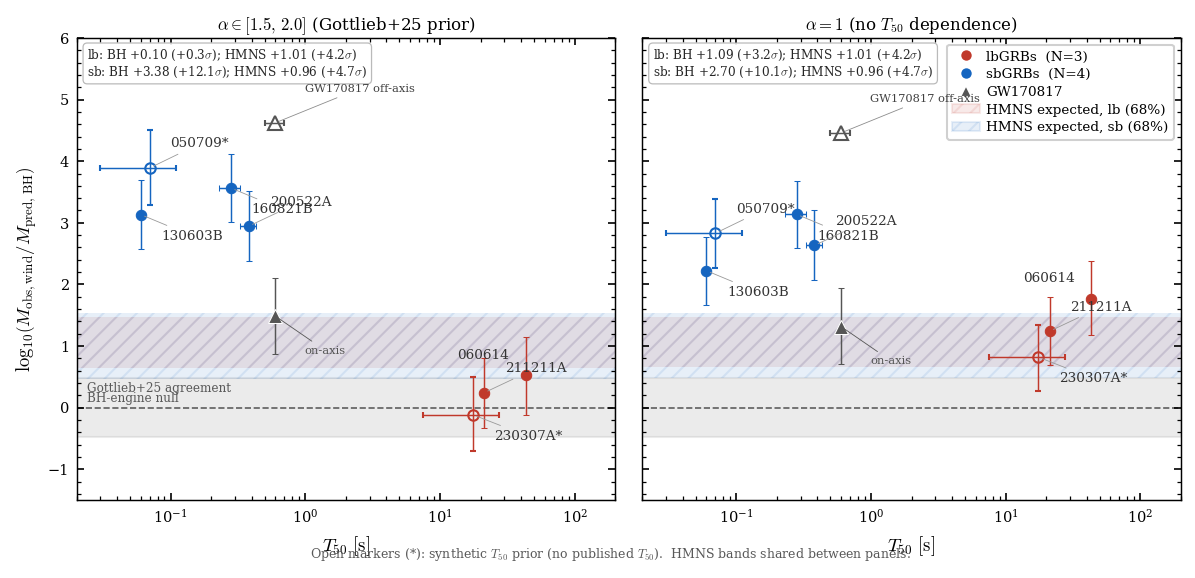

In [7]:
# Figure 4: side-by-side combination of Fig. 2 (Gottlieb+25 default
# alpha prior) and Fig. 3 (alpha = 1).  Shared y-axis, shared HMNS
# bands (HMNS prediction is alpha-independent), single legend on the
# right panel.  Use this as the headline figure for the alpha-prior
# robustness story; readers can sweep left to right and see exactly
# which residuals move when the T_50^{alpha-1} scaling is turned off.
fig4 = plot_fig2_combined(
    df, posteriors,
    savepath_pdf=os.path.join(PLOTS_DIR, "comparison_fig4.pdf"),
    alpha_range_left=(1.5, 2.0),
    alpha_range_right=(1.0, 1.0),
    stat_blocks=(stat_block, stat_block_a1),
)
plt.show()

### Figure 2: anchors and interpretation

**Anchors.** $y$-axis is the joint $\log_{10}(M_{\rm obs}/M_{\rm pred,BH})$ posterior per event, marginalising over $\alpha \in [1.5, 2]$ (Gottlieb+25 Eq. 11), $\log_{10} f$ uniform in $[-1.7, -0.15]$ ($f^{-1} \in [0.14, 5]$, same Berger 2014 / Beniamini+15 anchors as Fig. 1), Gaussian $E_{\gamma,\rm iso}$ and $T_{50}$ from `_CSV_LITERAL`, and the Rastinejad+24 split-normal $M_{\rm ej}$. Teal `+` replaces the BH denominator with $0.3\,M_d$ at log-uniform $M_d \in [0.01, 0.10]\,M_\odot$ (closer to the KF2020 NR-fit prior than linear-flat). Grey band: Gottlieb+25 factor-3 agreement criterion. GW170817 is an open triangle without a $y$-bar; its prompt $E_{\gamma,\rm iso} \sim 6 \times 10^{48}$ erg is off-axis cocoon emission (Goldstein+17, ApJL 848 L14; Mooley+18, Nature 561, 355), so Eq. 11 is misapplied.

**Interpretation.**

- **lbGRBs** (060614, 211211A, 230307A): $\langle \log_{10} R \rangle = +0.34$, $+0.8\sigma$ from the BH null. Consistent with the BH disk-wind picture; `log10 B10(HMNS/BH) ≈ -4` decisively prefers BH.
- **sbGRBs** (050709, 130603B, 160821B, 200522A): $\langle \log_{10} R \rangle = +3.45$, **$+9.7\sigma$ from the BH null**. Observed ejecta are $\sim 10^{3}\times$ heavier than a BH disk can supply for any plausible $(\alpha, f)$. The HMNS wind cuts the discrepancy to $\sim 1$ dex (teal crosses); `log10 B10(HMNS/BH) ≈ +23` overwhelmingly prefers HMNS.

The printed `log10 B10` are Gaussian-in-log Laplace approximations; treat as order-of-magnitude.

Bottom line: a BH accretion-disk engine is incompatible with sbGRB kilonovae at high confidence, motivating a long-lived HMNS / magnetar wind for the sbGRB class. This is Gottlieb+25's central result transcribed onto the Rastinejad+24 sample with an independent Monte-Carlo.

## E1. Observed-vs-model class fractions

Maps the Rastinejad et al. (2024) component decompositions $(M_B, M_P, M_R)$ onto the Gottlieb (2024) four-class engine taxonomy via `classify_observed_mergers`, then overlays the observed-sample class fractions on the model-population predictions from `grb_main.ipynb` Section 7.

**Mapping convention.** Three CODE HEURISTIC thresholds, defined in `grb_classify.py`:

| Constant | Meaning | Default |
|---|---|---|
| `KN_RED_FRAC_BLUE_MAX` | $f_R$ below which the source is `sbGRB + blue KN` | $0.30$ |
| `KN_RED_FRAC_RED_MIN` | $f_R$ above which the source is `lbGRB + red KN (disk)` | $0.70$ |
| `KN_M_EJ_FAINT_MAX` | $M_{\rm ej,total}$ below which the source is `Faint lbGRB` | $0.01\,M_\odot$ |

These are not Gottlieb (2024) values; the comparison's robustness is sensitive to the choice and is shown both at the defaults and at a tighter / looser pair below.

Rastinejad et al. (2024) sample: 8 sources, columns = ['name', 'grb_class', 'T50_s', 'T50_err_s', 'T50_ref', 'E_iso_52', 'E_iso_err52', 'E_iso_ref', 'M_B_med', 'M_B_lo', 'M_B_hi', 'M_P_med', 'M_P_lo', 'M_P_hi', 'M_R_med', 'M_R_lo', 'M_R_hi']
Model fractions: {'sbGRB + blue KN': 0.4584331025066175, 'lbGRB + red KN (HMNS)': 0.137560004725585, 'lbGRB + red KN (disk)': 0.2541470994641883, 'Faint lbGRB': 0.14985979330360905}
Observed fractions: {'sbGRB + blue KN': 0.25, 'lbGRB + red KN (HMNS)': 0.5, 'lbGRB + red KN (disk)': 0.25, 'Faint lbGRB': 0.0}


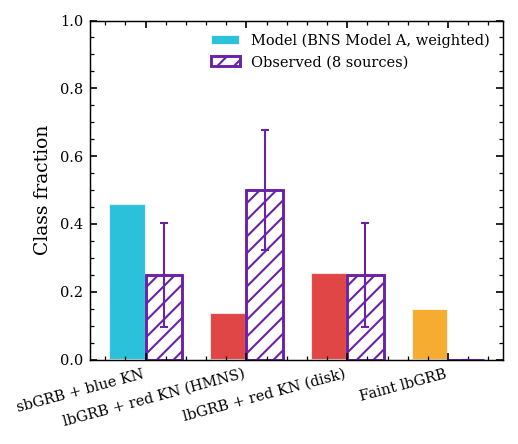

In [8]:
from grb_classify import classify_observed_mergers

# Load Rastinejad et al. (2024) component-decomposition table.  The CSV
# ships with a long `#`-prefixed header explaining provenance, then
# columns including the per-component medians and asymmetric +/-
# intervals: M_B_med, M_B_lo, M_B_hi, M_P_med, ... (Rastinejad+ 2024
# Table 3 medians; see the comments at the top of the CSV).
ras = pd.read_csv(CSV_PATH, comment='#', skipinitialspace=True)
print(f"Rastinejad et al. (2024) sample: {len(ras)} sources, columns = {list(ras.columns)}")

COL_BLUE = 'M_B_med'
COL_PURPLE = 'M_P_med'
COL_RED = 'M_R_med'

obs_cls = classify_observed_mergers(
    ras[COL_BLUE].to_numpy(),
    ras[COL_PURPLE].to_numpy(),
    ras[COL_RED].to_numpy(),
)
n_obs = len(ras)
class_keys = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
              'lbGRB + red KN (disk)', 'Faint lbGRB']
obs_fracs = {k: float(obs_cls[k].sum()) / n_obs for k in class_keys}

# Model-population class fractions: read from grb_main.ipynb's
# saved per-class rates if available, otherwise compute on the fly.
MODEL_FRAC_PATH = os.path.join('Plots', 'model_class_fractions.npy')
if os.path.exists(MODEL_FRAC_PATH):
    model_fracs_raw = np.load(MODEL_FRAC_PATH, allow_pickle=True).item()
else:
    # Fallback: compute from the BNS Model A catalog directly.
    from grb_io import load_bns
    from grb_classify import classify_bns_2024
    bns_a = load_bns()
    cls = classify_bns_2024(bns_a['m1'], bns_a['m2'])
    w = bns_a['weights']
    w_total = float(w.sum())
    model_fracs_raw = {k: float(w[cls[k]].sum()) / w_total for k in class_keys}
print('Model fractions:', model_fracs_raw)
print('Observed fractions:', obs_fracs)

class_colors = ['#06B6D4', '#DC2626', '#DC2626', '#F59E0B']
x = np.arange(len(class_keys))
width = 0.36

fig, ax = plt.subplots(figsize=(3.5, 3.0))
ax.bar(x - width / 2, [model_fracs_raw[k] for k in class_keys], width=width,
       color=class_colors, alpha=0.85, edgecolor='white',
       label='Model (BNS Model A, weighted)')
poisson_err = np.sqrt(np.array([obs_fracs[k] * (1 - obs_fracs[k]) / max(n_obs, 1)
                                for k in class_keys]))
ax.bar(x + width / 2, [obs_fracs[k] for k in class_keys], width=width,
       color='white', edgecolor='#6B21A8', linewidth=1.4,
       hatch='///',
       label=f'Observed ({n_obs} sources)')
ax.errorbar(x + width / 2, [obs_fracs[k] for k in class_keys],
            yerr=poisson_err, fmt='none', ecolor='#6B21A8',
            capsize=2, lw=1)
ax.set_xticks(x)
ax.set_xticklabels(class_keys, rotation=15, ha='right', fontsize=7)
ax.set_ylabel('Class fraction')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig('Plots/obs_class_fractions.pdf', bbox_inches='tight')
fig.savefig('Plots/obs_class_fractions.png', dpi=300, bbox_inches='tight')
plt.show()